## Cart Conversion Prediction
ShopSphere Technologies experiences significant revenue loss due to customers adding products to their 
shopping carts but failing to complete purchases. High cart abandonment rates negatively impact sales performance and marketing ROI.

### Business Problem
Business Context

The E-Commerce Department observed that a large percentage of customers add products to their shopping carts but leave the platform before completing checkout.

This behavior results in:
Lost revenue opportunities
Lower conversion rates
Reduced marketing effectiveness
Increased customer acquisition costs

### Business Objective

Predict whether a customer will complete a purchase after adding products to the cart.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedShuffleSplit
from imblearn.pipeline import Pipeline as imbpipeline

# Model packages
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier

from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import pickle
import warnings
warnings.simplefilter('ignore')

In [37]:
products = pd.read_csv("Products.csv")
website = pd.read_csv("Website_Activity.csv")
customers = pd.read_csv("Customer_Department_Targets.csv")
service = pd.read_csv("Customer_Service.csv")
orders = pd.read_csv("Orders.csv")

In [38]:
print(products.shape)
print(website.shape)
print(customers.shape)
print(service.shape)
print(orders.shape)

(10000, 12)
(300000, 10)
(50000, 25)
(100000, 8)
(300000, 12)


In [39]:
products.head()

,Product_ID,Product_Name,Category,Subcategory,Brand,Launch_Date,Unit_Cost,Selling_Price,Supplier_ID,Product_Rating,Return_Rate,Warranty_Months
0,P00001,Home Appliances Item 1,Home Appliances,Kitchen,Brand_96,2025-11-03,3978.73,7681.47,SUP0098,3.6,0.054,12
1,P00002,Fashion Item 2,Fashion,Womenswear,Brand_62,2019-01-07,1295.38,1892.03,SUP0369,4.1,0.045,0
2,P00003,Fashion Item 3,Fashion,Womenswear,Brand_53,2021-03-31,2612.59,3343.52,SUP0275,5.0,0.124,0
3,P00004,Fashion Item 4,Fashion,Womenswear,Brand_4,2024-08-28,602.44,979.35,SUP0297,2.9,0.196,0
4,P00005,Fashion Item 5,Fashion,Womenswear,Brand_72,2019-11-02,1307.00,2467.98,SUP0198,3.5,0.105,0


In [40]:
products.describe()

,Unit_Cost,Selling_Price,Product_Rating,Return_Rate,Warranty_Months
count,10000.000000,10000.000000,9500.000000,10000.000000,10000.000000
mean,5834.715889,9174.579294,3.785084,0.067196,9.650400
std,7286.399198,11181.076147,0.629771,0.049394,12.616691
min,39.700000,75.310000,1.000000,0.005000,0.000000
25%,664.137500,1060.300000,3.400000,0.031000,0.000000
50%,2562.030000,4121.125000,3.800000,0.058000,0.000000
75%,8853.000000,14139.822500,4.200000,0.092000,12.000000
max,65464.820000,108712.500000,5.000000,0.293000,36.000000


In [41]:
products.isnull().sum()

Product_ID           0
Product_Name         0
Category             0
Subcategory          0
Brand                0
Launch_Date          0
Unit_Cost            0
Selling_Price        0
Supplier_ID          0
Product_Rating     500
Return_Rate          0
Warranty_Months      0
dtype: int64

In [42]:
customers.head()

,Customer_ID,Age,Loyalty_Tier,Credit_Score,Tenure_Months,Last_Login_Days_Ago,Total_Orders,Total_Revenue,Avg_Order_Value,Total_Quantity,...,Campaign_Open_Rate,Campaign_Click_Rate,Campaign_Response_Rate,Total_Sessions,Avg_Pages_Viewed,Cart_Rate,Web_Purchase_Rate,Churn_Flag,Future_VIP_Flag,Customer_Lifetime_Value
0,C000001,36,Gold,561,74,16,4,79175.68,19793.92,10,...,0.000,0.000,0.000,6,7.83,0.667,0.500,0,1,99517.80
1,C000002,18,Gold,773,52,44,10,217064.36,21706.44,33,...,0.000,0.000,0.000,8,8.25,0.625,0.000,0,1,233743.31
2,C000003,42,Bronze,640,53,118,6,184845.42,30807.57,89,...,0.333,0.333,0.000,10,6.40,0.300,0.300,1,1,207706.73
3,C000004,37,Silver,801,8,0,3,91837.28,30612.43,5,...,0.667,0.333,0.333,8,9.38,0.750,0.625,0,0,104561.78
4,C000005,30,Silver,659,52,126,3,39718.23,13239.41,5,...,0.000,0.333,0.333,4,8.00,0.750,0.250,0,0,48705.81


In [43]:
customers.describe()

,Age,Credit_Score,Tenure_Months,Last_Login_Days_Ago,Total_Orders,Total_Revenue,Avg_Order_Value,Total_Quantity,Recency_Days,Total_Tickets,...,Campaign_Open_Rate,Campaign_Click_Rate,Campaign_Response_Rate,Total_Sessions,Avg_Pages_Viewed,Cart_Rate,Web_Purchase_Rate,Churn_Flag,Future_VIP_Flag,Customer_Lifetime_Value
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,5.000000e+04,50000.000000,50000.000000,50000.0,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04
mean,36.161380,692.523460,60.47130,52.246880,6.00000,1.348356e+05,22323.957731,18.688180,365.0,2.000000,...,0.217578,0.116107,0.059970,6.000000,7.173606,0.533067,0.255641,0.426160,0.55298,1.617312e+05
std,10.526712,72.969886,34.76138,47.135348,2.45396,1.379509e+05,22349.317507,12.050617,0.0,1.414157,...,0.322620,0.246562,0.181894,2.443391,1.795062,0.240331,0.210753,0.494523,0.49719,1.663199e+05
min,18.000000,342.000000,1.00000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,365.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000e+00
25%,28.000000,643.000000,30.00000,19.000000,4.00000,5.589742e+04,10847.217500,11.000000,365.0,1.000000,...,0.000000,0.000000,0.000000,4.000000,6.000000,0.375000,0.100000,0.000000,0.00000,6.670493e+04
50%,36.000000,693.000000,60.00000,41.000000,6.00000,1.036433e+05,17752.190000,16.000000,365.0,2.000000,...,0.000000,0.000000,0.000000,6.000000,7.000000,0.500000,0.250000,0.000000,1.00000,1.238571e+05
75%,43.000000,743.000000,91.00000,73.000000,8.00000,1.719721e+05,27157.900000,22.000000,365.0,3.000000,...,0.400000,0.000000,0.000000,8.000000,8.250000,0.667000,0.400000,1.000000,1.00000,2.065792e+05
max,75.000000,850.000000,120.00000,365.000000,19.00000,2.590141e+06,651847.470000,118.000000,365.0,13.000000,...,1.000000,1.000000,1.000000,19.000000,20.000000,1.000000,1.000000,1.000000,1.00000,3.267617e+06


In [44]:
customers.isnull().sum()

Customer_ID                0
Age                        0
Loyalty_Tier               0
Credit_Score               0
Tenure_Months              0
Last_Login_Days_Ago        0
Total_Orders               0
Total_Revenue              0
Avg_Order_Value            0
Total_Quantity             0
Recency_Days               0
Total_Tickets              0
Avg_Satisfaction           0
Escalation_Rate            0
Campaigns_Received         0
Campaign_Open_Rate         0
Campaign_Click_Rate        0
Campaign_Response_Rate     0
Total_Sessions             0
Avg_Pages_Viewed           0
Cart_Rate                  0
Web_Purchase_Rate          0
Churn_Flag                 0
Future_VIP_Flag            0
Customer_Lifetime_Value    0
dtype: int64

In [45]:
service.head()

,Ticket_ID,Customer_ID,Ticket_Date,Issue_Category,Priority,Resolution_Time_Hours,Escalated,Satisfaction_Score
0,T0000001,C039316,2023-06-14,Payment,Medium,23.0,0,5.0
1,T0000002,C039941,2023-09-02,Delivery,Medium,17.6,0,5.0
2,T0000003,C035258,2024-01-28,Return,High,12.2,0,4.0
3,T0000004,C015157,2025-05-01,Return,High,14.3,0,3.0
4,T0000005,C016965,2025-09-12,Payment,Medium,8.9,0,5.0


In [46]:
service.describe()

,Resolution_Time_Hours,Escalated,Satisfaction_Score
count,100000.000000,100000.000000,95000.000000
mean,21.630311,0.140050,3.975368
std,13.959021,0.347041,0.998184
min,0.000000,0.000000,1.000000
25%,11.400000,0.000000,3.000000
50%,18.700000,0.000000,4.000000
75%,28.800000,0.000000,5.000000
max,140.100000,1.000000,5.000000


In [47]:
service.isnull().sum()

Ticket_ID                   0
Customer_ID                 0
Ticket_Date                 0
Issue_Category              0
Priority                    0
Resolution_Time_Hours       0
Escalated                   0
Satisfaction_Score       5000
dtype: int64

In [48]:
orders.head()

,Order_ID,Customer_ID,Product_ID,Store_ID,Order_Date,Quantity,Unit_Price,Discount,Final_Amount,Payment_Method,Delivery_Mode,Order_Status
0,O00000001,C003674,P03674,ST0229,2023-06-18,4,23920.32,0.18,78458.65,Wallet,Express,Delivered
1,O00000002,C008655,P05805,ST0085,2025-01-27,36,15313.15,0.11,490633.33,Net Banking,Store Pickup,Delivered
2,O00000003,C025900,P07096,ST0147,2025-08-26,3,2651.99,0.45,4375.78,Credit Card,Express,Delivered
3,O00000004,C005038,P03625,ST0143,2023-09-20,1,184.85,0.58,77.64,Wallet,Same Day,Cancelled
4,O00000005,C010377,P02172,ST0237,2025-08-16,3,8234.39,0.03,23962.07,Credit Card,Standard,In Transit


In [49]:
orders.describe()

,Quantity,Unit_Price,Discount,Final_Amount
count,300000.000000,300000.000000,289500.000000,3.000000e+05
mean,3.114697,9158.577573,0.226670,2.247260e+04
std,3.779130,11185.722920,0.122861,5.145227e+04
min,1.000000,69.300000,0.000000,3.205000e+01
25%,2.000000,1067.810000,0.130000,1.859020e+03
50%,3.000000,4107.330000,0.210000,7.751800e+03
75%,4.000000,14097.400000,0.300000,2.738411e+04
max,51.000000,117398.610000,0.750000,2.402881e+06


In [50]:
orders.isnull().sum()

Order_ID              0
Customer_ID           0
Product_ID            0
Store_ID              0
Order_Date            0
Quantity              0
Unit_Price            0
Discount          10500
Final_Amount          0
Payment_Method        0
Delivery_Mode      3600
Order_Status          0
dtype: int64

In [51]:
website.head()

,Session_ID,Customer_ID,Visit_Date,Device_Type,Traffic_Source,Pages_Viewed,Session_Duration,Added_To_Cart,Purchased,Purchase_After_Cart
0,WEB00000001,C005389,2023-05-13,Android,Organic,2,13.5,1,0,0
1,WEB00000002,C018911,2023-09-24,Android,Organic,3,2.9,0,0,0
2,WEB00000003,C023172,2023-04-03,Android,Direct,10,10.9,1,1,1
3,WEB00000004,C048564,2023-01-20,iOS,Paid Search,10,9.2,1,0,0
4,WEB00000005,C047040,2025-09-16,iOS,Organic,12,3.2,0,0,0


In [52]:
website.describe()

,Pages_Viewed,Session_Duration,Added_To_Cart,Purchased,Purchase_After_Cart
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,7.193877,8.250419,0.534377,0.256580,0.169947
std,2.825301,5.407376,0.498818,0.436746,0.375587
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,4.300000,0.000000,0.000000,0.000000
50%,7.000000,7.100000,1.000000,0.000000,0.000000
75%,9.000000,11.000000,1.000000,1.000000,0.000000
max,24.000000,55.500000,1.000000,1.000000,1.000000


In [53]:
website.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Session_ID           300000 non-null  object 
 1   Customer_ID          300000 non-null  object 
 2   Visit_Date           300000 non-null  object 
 3   Device_Type          300000 non-null  object 
 4   Traffic_Source       294000 non-null  object 
 5   Pages_Viewed         300000 non-null  int64  
 6   Session_Duration     300000 non-null  float64
 7   Added_To_Cart        300000 non-null  int64  
 8   Purchased            300000 non-null  int64  
 9   Purchase_After_Cart  300000 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 22.9+ MB


In [54]:
website.isnull().sum()

Session_ID                0
Customer_ID               0
Visit_Date                0
Device_Type               0
Traffic_Source         6000
Pages_Viewed              0
Session_Duration          0
Added_To_Cart             0
Purchased                 0
Purchase_After_Cart       0
dtype: int64

In [55]:
'''
Required columns
All other columns are removed from website.
'''

website = website[
[
'Customer_ID',
'Device_Type',
'Traffic_Source',
'Pages_Viewed',
'Session_Duration',
'Added_To_Cart',
'Purchase_After_Cart'
]
]

In [56]:
'''
Required columns
All other columns are removed from website.
'''
customers = customers[
[
'Customer_ID',
'Loyalty_Tier',
'Tenure_Months',
'Last_Login_Days_Ago',
'Total_Orders',
'Avg_Order_Value',
'Recency_Days',
'Customer_Lifetime_Value',
'Campaign_Click_Rate',
'Avg_Satisfaction'
]
]

In [57]:
'''
How many customers abandoned their cart and how many completed their purchase.
'''

website['Purchase_After_Cart'].value_counts()

Purchase_After_Cart
0    249016
1     50984
Name: count, dtype: int64

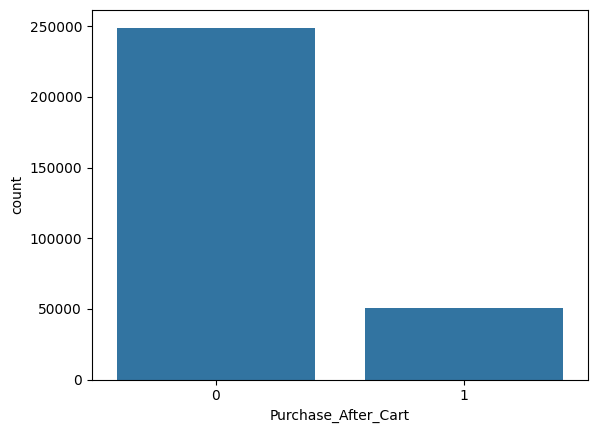

In [58]:
sns.countplot(x='Purchase_After_Cart', data=website)
plt.show()

In [59]:
customers.shape

(50000, 10)

In [60]:
customers['Customer_ID'].nunique()

50000

In [61]:
customers['Customer_ID'].duplicated().sum()

np.int64(0)

In [62]:
website['Customer_ID'].duplicated().sum()

np.int64(250127)

In [63]:
'''Feature Engineering
This step is done because your Customer_Service table has multiple records per customer, 
while your model needs one row per customer when joining data.
Customer C001 has 3 tickets
Customer C002 has 1 ticket
If you directly join this table to your website data, you'll create duplicate rows.
'''

service_agg = service.groupby('Customer_ID').agg({
    'Satisfaction_Score':'mean'
}).reset_index()

service_agg.rename(columns={
    'Satisfaction_Score':'Avg_Service_Satisfaction'
}, inplace=True)

service_agg.head()

,Customer_ID,Avg_Service_Satisfaction
0,C000001,4.0
1,C000002,5.0
2,C000003,3.5
3,C000004,4.0
4,C000005,5.0


In [64]:
order_product = orders.merge(
    products,
    on='Product_ID',
    how='left'
)

In [65]:
product_agg = order_product.groupby('Customer_ID').agg({
    'Product_Rating':'mean',
    'Selling_Price':'mean',
    'Return_Rate':'mean'
}).reset_index()

product_agg.columns = [
    'Customer_ID',
    'Avg_Product_Rating',
    'Avg_Product_Price',
    'Avg_Return_Rate'
]

product_agg.head()

,Customer_ID,Avg_Product_Rating,Avg_Product_Price,Avg_Return_Rate
0,C000001,3.800000,9091.187500,0.034750
1,C000002,3.610000,8256.527000,0.067900
2,C000003,4.066667,9674.455000,0.079000
3,C000004,3.700000,18832.630000,0.085667
4,C000005,3.200000,11729.753333,0.021667


In [66]:
df = website.merge(
    customers,
    on='Customer_ID',
    how='left'
)

In [67]:
df = df.merge(
    service_agg,
    on='Customer_ID',
    how='left'
)

In [68]:
df = df.merge(
    product_agg,
    on='Customer_ID',
    how='left'
)

In [69]:
df.columns

Index(['Customer_ID', 'Device_Type', 'Traffic_Source', 'Pages_Viewed',
       'Session_Duration', 'Added_To_Cart', 'Purchase_After_Cart',
       'Loyalty_Tier', 'Tenure_Months', 'Last_Login_Days_Ago', 'Total_Orders',
       'Avg_Order_Value', 'Recency_Days', 'Customer_Lifetime_Value',
       'Campaign_Click_Rate', 'Avg_Satisfaction', 'Avg_Service_Satisfaction',
       'Avg_Product_Rating', 'Avg_Product_Price', 'Avg_Return_Rate'],
      dtype='object')

In [70]:
df.shape

(300000, 20)

In [71]:
customers['Customer_ID'].nunique()
customers['Customer_ID'].duplicated().sum()

np.int64(0)

In [72]:
df.isnull().sum()

Customer_ID                     0
Device_Type                     0
Traffic_Source               6000
Pages_Viewed                    0
Session_Duration                0
Added_To_Cart                   0
Purchase_After_Cart             0
Loyalty_Tier                    0
Tenure_Months                   0
Last_Login_Days_Ago             0
Total_Orders                    0
Avg_Order_Value                 0
Recency_Days                    0
Customer_Lifetime_Value         0
Campaign_Click_Rate             0
Avg_Satisfaction                0
Avg_Service_Satisfaction    45407
Avg_Product_Rating            963
Avg_Product_Price             704
Avg_Return_Rate               704
dtype: int64

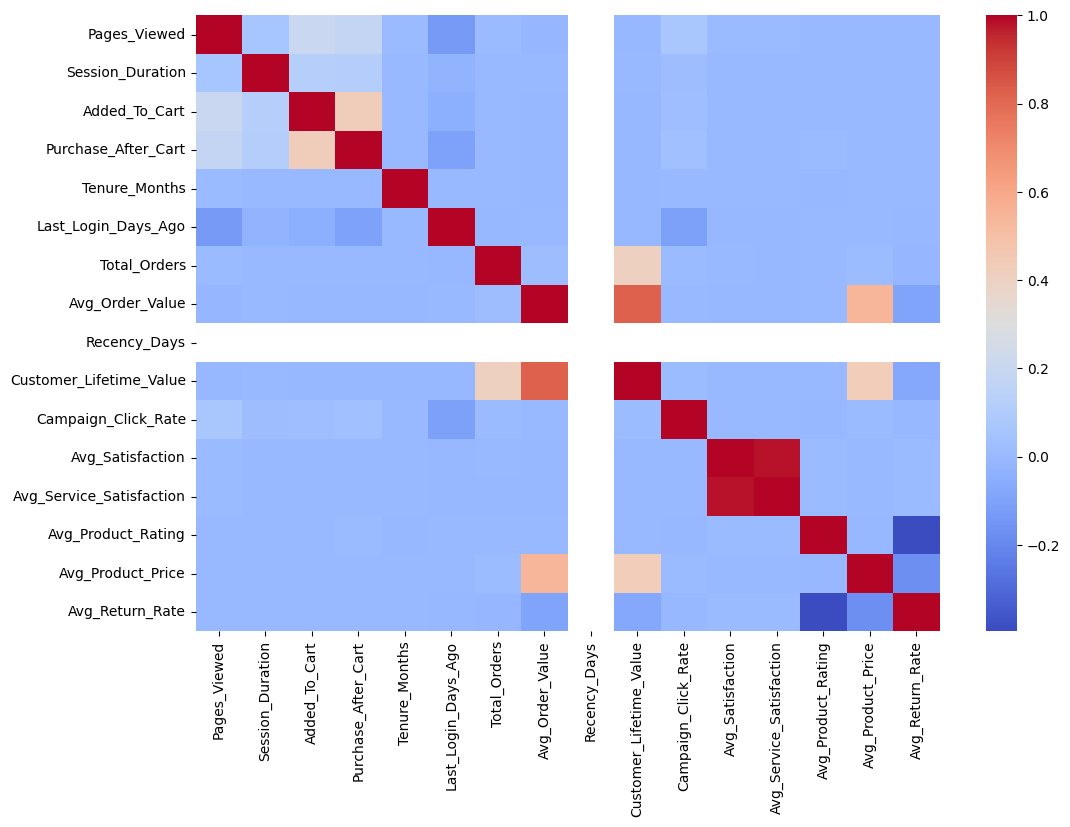

In [73]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,cmap='coolwarm')
plt.show()

In [74]:
''''
Customers in different loyalty tiers often have different service experiences.
Bronze customers → lower satisfaction
Platinum customers → higher satisfaction
'''

df['Avg_Service_Satisfaction'] = df.groupby('Loyalty_Tier')[
    'Avg_Service_Satisfaction'
].transform(
    lambda x: x.fillna(x.median())
)

In [75]:
'''
Different devices often come from different traffic channels.
Desktop users → Organic Search
Mobile users → Social Media
'''

df['Avg_Product_Rating'] = df.groupby('Traffic_Source')[
    'Avg_Product_Rating'
].transform(
    lambda x: x.fillna(x.median())
)

In [76]:
'''
Higher-tier customers may buy different products than lower-tier customers.
'''

df['Avg_Product_Price'] = df.groupby('Loyalty_Tier')[
    'Avg_Product_Price'
].transform(
    lambda x: x.fillna(x.median())
)

In [77]:
'''
Return behavior can differ by customer segment.
'''

df['Avg_Return_Rate'] = df.groupby('Loyalty_Tier')[
    'Avg_Return_Rate'
].transform(
    lambda x: x.fillna(x.median())
)

In [78]:
'''Desktop users → mostly Organic
Mobile users → mostly Social
This is better than filling every missing value with the global mode.
'''

df['Traffic_Source'] = df.groupby('Device_Type')[
    'Traffic_Source'
].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Direct')
)

In [79]:
df.isnull().sum().sort_values(ascending=False)

Avg_Product_Rating          6000
Customer_ID                    0
Traffic_Source                 0
Device_Type                    0
Pages_Viewed                   0
Session_Duration               0
Purchase_After_Cart            0
Added_To_Cart                  0
Tenure_Months                  0
Last_Login_Days_Ago            0
Total_Orders                   0
Loyalty_Tier                   0
Avg_Order_Value                0
Recency_Days                   0
Campaign_Click_Rate            0
Customer_Lifetime_Value        0
Avg_Satisfaction               0
Avg_Service_Satisfaction       0
Avg_Product_Price              0
Avg_Return_Rate                0
dtype: int64

In [80]:
'''After groupby sometimes have some 
missing values so final null fill imputation.
'''

df['Avg_Service_Satisfaction'].fillna(
    df['Avg_Service_Satisfaction'].median(),
    inplace=True
)

df['Avg_Product_Rating'].fillna(
    df['Avg_Product_Rating'].median(),
    inplace=True
)

df['Avg_Product_Price'].fillna(
    df['Avg_Product_Price'].median(),
    inplace=True
)

df['Avg_Return_Rate'].fillna(
    df['Avg_Return_Rate'].median(),
    inplace=True
)

In [81]:
df.isnull().sum().sort_values(ascending=False)

Customer_ID                 0
Device_Type                 0
Traffic_Source              0
Pages_Viewed                0
Session_Duration            0
Added_To_Cart               0
Purchase_After_Cart         0
Loyalty_Tier                0
Tenure_Months               0
Last_Login_Days_Ago         0
Total_Orders                0
Avg_Order_Value             0
Recency_Days                0
Customer_Lifetime_Value     0
Campaign_Click_Rate         0
Avg_Satisfaction            0
Avg_Service_Satisfaction    0
Avg_Product_Rating          0
Avg_Product_Price           0
Avg_Return_Rate             0
dtype: int64

In [82]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['Pages_Viewed', 'Session_Duration', 'Added_To_Cart',
       'Purchase_After_Cart', 'Tenure_Months', 'Last_Login_Days_Ago',
       'Total_Orders', 'Avg_Order_Value', 'Recency_Days',
       'Customer_Lifetime_Value', 'Campaign_Click_Rate', 'Avg_Satisfaction',
       'Avg_Service_Satisfaction', 'Avg_Product_Rating', 'Avg_Product_Price',
       'Avg_Return_Rate'],
      dtype='object')

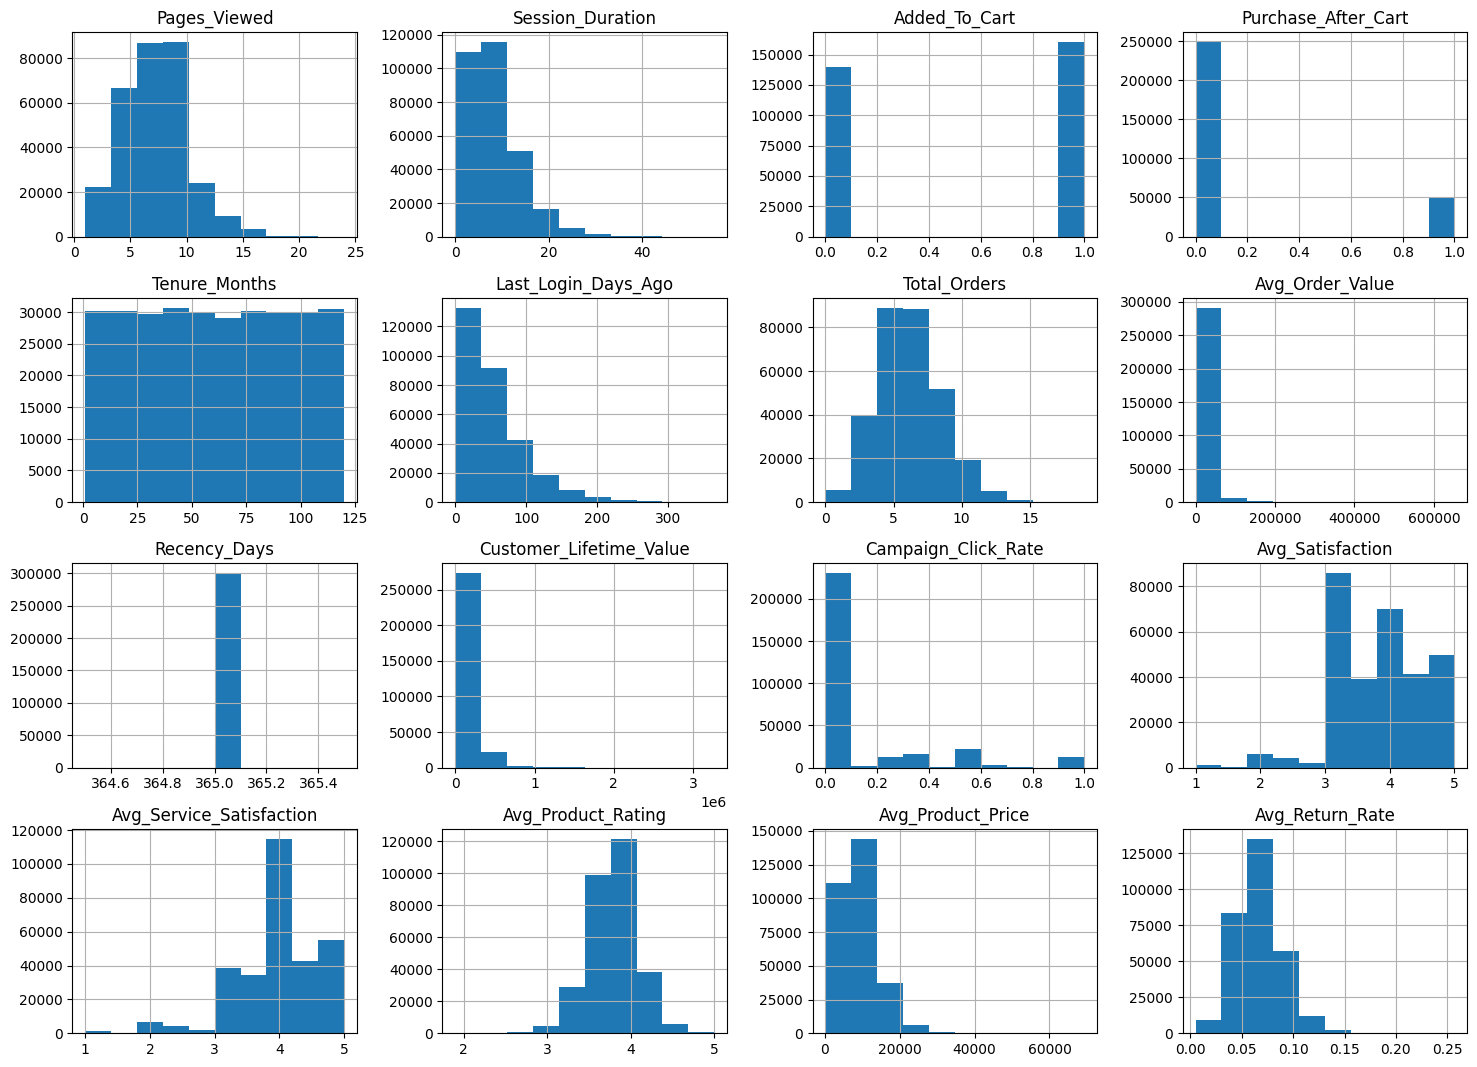

In [83]:
df[num_cols].hist(figsize=(18,13))
plt.show()

In [84]:
'''
Counts customers in each Loyalty Tier based on whether they purchased or abandoned their cart.
'''

pivot_table = pd.pivot_table(
    df,
    index='Loyalty_Tier',
    columns='Purchase_After_Cart',
    values='Customer_ID',
    aggfunc='count'
)

pivot_table = pivot_table.div(
    pivot_table.sum(axis=1),
    axis=0
) * 100

pivot_table.round(2)

Purchase_After_Cart,0,1
Loyalty_Tier,,
Bronze,88.82,11.18
Gold,74.12,25.88
Platinum,65.50,34.50
Silver,81.76,18.24


In [85]:
device_pivot = pd.pivot_table(
    df,
    index='Device_Type',
    columns='Purchase_After_Cart',
    values='Customer_ID',
    aggfunc='count'
)

device_pivot = device_pivot.div(
    device_pivot.sum(axis=1),
    axis=0
) * 100

device_pivot.round(2)

Purchase_After_Cart,0,1
Device_Type,,
Android,82.98,17.02
Desktop,83.03,16.97
Tablet,83.20,16.80
iOS,82.98,17.02


In [86]:
traffic_pivot = pd.pivot_table(
    df,
    index='Traffic_Source',
    columns='Purchase_After_Cart',
    values='Customer_ID',
    aggfunc='count'
)

traffic_pivot = traffic_pivot.div(
    traffic_pivot.sum(axis=1),
    axis=0
) * 100

traffic_pivot.round(2)

Purchase_After_Cart,0,1
Traffic_Source,,
Direct,82.77,17.23
Organic,83.18,16.82
Paid Search,83.01,16.99
Referral,82.98,17.02
Social,82.90,17.10


In [87]:
'''
Purchasers view more pages.
More engagement leads to more conversions.
'''
df.groupby('Purchase_After_Cart')['Pages_Viewed'].mean().round(2)

Purchase_After_Cart
0    6.96
1    8.32
Name: Pages_Viewed, dtype: float64

In [88]:
'''
Customers spending more time are more likely to buy.
'''
df.groupby('Purchase_After_Cart')['Session_Duration'].mean().round(2)

Purchase_After_Cart
0    7.97
1    9.62
Name: Session_Duration, dtype: float64

In [89]:
'''
High-spending customers convert more often.
'''
df.groupby('Purchase_After_Cart')['Avg_Order_Value'].mean().round(2)

Purchase_After_Cart
0    22391.79
1    22065.21
Name: Avg_Order_Value, dtype: float64

In [90]:
'''
Customers who engage with campaigns are more likely to purchase.
'''
df.groupby('Purchase_After_Cart')['Campaign_Click_Rate'].mean().round(2)

Purchase_After_Cart
0    0.11
1    0.13
Name: Campaign_Click_Rate, dtype: float64

In [91]:
'''
Higher-rated products lead to higher conversion.
'''
df.groupby('Purchase_After_Cart')['Avg_Product_Rating'].mean().round(2)

Purchase_After_Cart
0    3.79
1    3.79
Name: Avg_Product_Rating, dtype: float64

In [92]:
'''
Shows whether expensive products reduce conversions or attract serious buyers.
'''
df.groupby('Purchase_After_Cart')['Avg_Product_Price'].mean().round(2)

Purchase_After_Cart
0    9152.31
1    9150.37
Name: Avg_Product_Price, dtype: float64

In [93]:
'''
Satisfied customers are more likely to complete purchases.
'''
df.groupby('Purchase_After_Cart')['Avg_Service_Satisfaction'].mean().round(2)

Purchase_After_Cart
0    3.98
1    3.98
Name: Avg_Service_Satisfaction, dtype: float64

In [94]:
'''
Recently active customers convert more.
'''
df.groupby('Purchase_After_Cart')['Last_Login_Days_Ago'].mean().round(2)

Purchase_After_Cart
0    54.61
1    41.35
Name: Last_Login_Days_Ago, dtype: float64

In [95]:
'''
Long-term customers trust ShopSphere more and therefore have higher conversion rates.
'''
df.groupby('Purchase_After_Cart')['Tenure_Months'].mean().round(2)

Purchase_After_Cart
0    60.46
1    60.59
Name: Tenure_Months, dtype: float64

In [96]:
# Unique device types
df['Device_Type'].unique()

array(['Android', 'iOS', 'Tablet', 'Desktop'], dtype=object)

In [97]:
#unique traffic source
df['Traffic_Source'].unique()

array(['Organic', 'Direct', 'Paid Search', 'Social', 'Referral'],
      dtype=object)

In [98]:
#Unique Loyalty tier
df['Loyalty_Tier'].unique()

array(['Silver', 'Platinum', 'Gold', 'Bronze'], dtype=object)

In [99]:
'''
Encoding : Categorical variables
'''

df = pd.get_dummies(
    df,
    columns=['Device_Type', 'Traffic_Source', 'Loyalty_Tier'],
    drop_first=True
)

In [100]:
df.shape

(300000, 27)

In [101]:
X = df.drop('Purchase_After_Cart', axis=1)

y = df['Purchase_After_Cart']

In [102]:
X = X.drop('Customer_ID', axis=1)

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [105]:
y_pred = rf.predict(X_test)

In [106]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(" BEFORE SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

 BEFORE SMOTE
Accuracy: 0.8267
              precision    recall  f1-score   support

           0       0.84      0.98      0.90     49803
           1       0.45      0.10      0.16     10197

    accuracy                           0.83     60000
   macro avg       0.65      0.54      0.53     60000
weighted avg       0.78      0.83      0.78     60000



In [143]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [144]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [145]:
y_pred = rf.predict(X_test)

In [146]:
from sklearn.metrics import accuracy_score, classification_report

print("AFTER SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

AFTER SMOTE
Accuracy: 0.7697
              precision    recall  f1-score   support

           0       0.90      0.81      0.85     49803
           1       0.38      0.56      0.45     10197

    accuracy                           0.77     60000
   macro avg       0.64      0.69      0.65     60000
weighted avg       0.81      0.77      0.79     60000



In [107]:
'''
Smote was used because the target variable was imbalanced.
before smote accuracy is high But this accuracy was misleading.
so we are appliying smote.
After smote Training data becomes balanced.
'''

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [137]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=15, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [138]:
y_pred = rf.predict(X_test)

In [139]:
from sklearn.metrics import accuracy_score, classification_report
print("AFTER SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

AFTER SMOTE
Accuracy: 0.7697
              precision    recall  f1-score   support

           0       0.90      0.81      0.85     49803
           1       0.38      0.56      0.45     10197

    accuracy                           0.77     60000
   macro avg       0.64      0.69      0.65     60000
weighted avg       0.81      0.77      0.79     60000



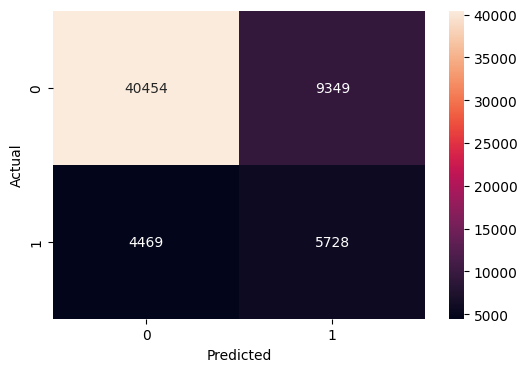

In [111]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [112]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                       Feature  Importance
2                Added_To_Cart    0.513057
22           Loyalty_Tier_Gold    0.065524
24         Loyalty_Tier_Silver    0.041961
23       Loyalty_Tier_Platinum    0.040016
18      Traffic_Source_Organic    0.037950
19  Traffic_Source_Paid Search    0.037334
21       Traffic_Source_Social    0.031376
10            Avg_Satisfaction    0.025471
9          Campaign_Click_Rate    0.023366
1             Session_Duration    0.023354
17             Device_Type_iOS    0.022443
15         Device_Type_Desktop    0.021896
11    Avg_Service_Satisfaction    0.020090
4          Last_Login_Days_Ago    0.017258
20     Traffic_Source_Referral    0.016629


In [113]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

In [114]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7957
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     49803
           1       0.40      0.40      0.40     10197

    accuracy                           0.80     60000
   macro avg       0.64      0.64      0.64     60000
weighted avg       0.80      0.80      0.80     60000



In [115]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                       Feature  Importance
2                Added_To_Cart    0.637222
24         Loyalty_Tier_Silver    0.051633
22           Loyalty_Tier_Gold    0.048423
23       Loyalty_Tier_Platinum    0.038106
19  Traffic_Source_Paid Search    0.032084
21       Traffic_Source_Social    0.030395
18      Traffic_Source_Organic    0.027067
17             Device_Type_iOS    0.026319
20     Traffic_Source_Referral    0.023756
15         Device_Type_Desktop    0.023710
9          Campaign_Click_Rate    0.013871
16          Device_Type_Tablet    0.011436
10            Avg_Satisfaction    0.010362
11    Avg_Service_Satisfaction    0.009543
1             Session_Duration    0.004333


In [116]:
X.columns

Index(['Pages_Viewed', 'Session_Duration', 'Added_To_Cart', 'Tenure_Months',
       'Last_Login_Days_Ago', 'Total_Orders', 'Avg_Order_Value',
       'Recency_Days', 'Customer_Lifetime_Value', 'Campaign_Click_Rate',
       'Avg_Satisfaction', 'Avg_Service_Satisfaction', 'Avg_Product_Rating',
       'Avg_Product_Price', 'Avg_Return_Rate', 'Device_Type_Desktop',
       'Device_Type_Tablet', 'Device_Type_iOS', 'Traffic_Source_Organic',
       'Traffic_Source_Paid Search', 'Traffic_Source_Referral',
       'Traffic_Source_Social', 'Loyalty_Tier_Gold', 'Loyalty_Tier_Platinum',
       'Loyalty_Tier_Silver'],
      dtype='object')

In [117]:
cols_to_drop = [
    'Total_Orders',
    'Avg_Order_Value',
    'Customer_Lifetime_Value'
]

X_new = X.drop(columns=cols_to_drop)

In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [119]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)

In [120]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7433166666666666
              precision    recall  f1-score   support

           0       0.91      0.77      0.83     49803
           1       0.36      0.63      0.46     10197

    accuracy                           0.74     60000
   macro avg       0.63      0.70      0.64     60000
weighted avg       0.82      0.74      0.77     60000



In [121]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)

In [122]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.76395
              precision    recall  f1-score   support

           0       0.90      0.80      0.85     49803
           1       0.38      0.58      0.46     10197

    accuracy                           0.76     60000
   macro avg       0.64      0.69      0.65     60000
weighted avg       0.81      0.76      0.78     60000



In [123]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest + SMOTE": y_pred,
    "XGBoost + SMOTE": y_pred_xgb
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

In [124]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.743317,0.355941,0.630480,0.455005
1,Decision Tree,0.763950,0.375220,0.584780,0.457128
2,Random Forest + SMOTE,0.769700,0.379916,0.561734,0.453272
3,XGBoost + SMOTE,0.795700,0.398742,0.397960,0.398351


In [125]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=True
)

importance.tail(10)

,Feature,Importance
0,Pages_Viewed,0.052992
3,Tenure_Months,0.065048
12,Avg_Product_Rating,0.066838
4,Last_Login_Days_Ago,0.067321
8,Customer_Lifetime_Value,0.067896
6,Avg_Order_Value,0.068080
13,Avg_Product_Price,0.070130
14,Avg_Return_Rate,0.070528
1,Session_Duration,0.094503
2,Added_To_Cart,0.168930


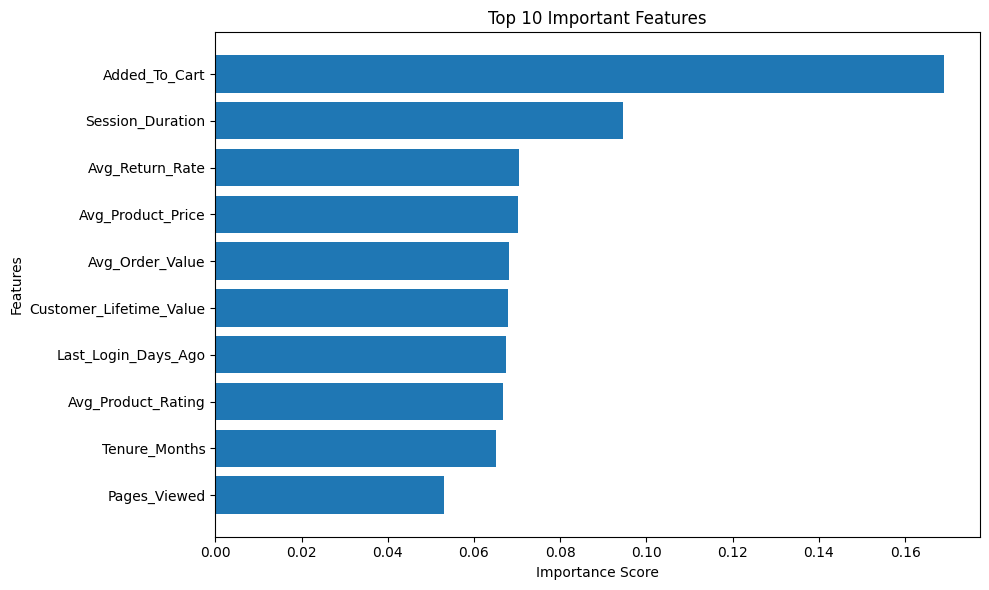

In [126]:
import matplotlib.pyplot as plt

top_features = importance.tail(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

### We built a system that helps ShopSphere understand which customers are likely to buy and which might leave without purchasing.

### Conclusion

A Cart Conversion Prediction system was successfully developed using customer behavior,
website activity, marketing engagement, product information, and customer satisfaction data.

Multiple machine learning algorithms were evaluated, including Logistic Regression, 
Decision Tree, Random Forest, and XGBoost. Among these, the Decision Tree model 
achieved the highest F1 Score of 45.71%, providing the best balance between precision and recall while maintaining interpretability.

The solution provides actionable insights that can help ShopSphere increase conversions, 
recover revenue, and improve customer experience through data-driven decision-making.

### The system studies customer behavior like:

 How they browse the website
 
 What products they view
 
 Whether they respond to offers
 
 Their past activity
 
 Engagement with marketing messages

Then it learns patterns and predicts future behavior.

### 1] Identify High-Risk Customers

The model can identify customers who are likely to abandon their carts before they leave the website.

### 2] Personalized Retargeting(for customers predicted as non-converters) :

Reminder emails

Push notifications

Discount coupons

Limited-time offers

### 3] Focus marketing on the right people
Instead of targeting everyone, focus only on customers who need motivation to buy.

### 4] Improve Marketing ROI

Instead of targeting all customers, marketing efforts can focus on customers who need intervention.


In [136]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [147]:
print(X_train.columns)
print(len(X_train.columns))

Index(['Pages_Viewed', 'Session_Duration', 'Added_To_Cart', 'Tenure_Months',
       'Last_Login_Days_Ago', 'Total_Orders', 'Avg_Order_Value',
       'Recency_Days', 'Customer_Lifetime_Value', 'Campaign_Click_Rate',
       'Avg_Satisfaction', 'Avg_Service_Satisfaction', 'Avg_Product_Rating',
       'Avg_Product_Price', 'Avg_Return_Rate', 'Device_Type_Desktop',
       'Device_Type_Tablet', 'Device_Type_iOS', 'Traffic_Source_Organic',
       'Traffic_Source_Paid Search', 'Traffic_Source_Referral',
       'Traffic_Source_Social', 'Loyalty_Tier_Gold', 'Loyalty_Tier_Platinum',
       'Loyalty_Tier_Silver'],
      dtype='object')
25


In [148]:
import joblib

In [149]:
joblib.dump(model, "model.pkl")

['model.pkl']

In [150]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [151]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']